In [1]:
import os
import joblib
import numpy as np
import pandas as pd

save_dir = r"C:\Users\USER\Desktop\MS -Thesis\Results\hmm_3d_diag_50k"

results_df = pd.read_csv(os.path.join(save_dir,"results_summary.csv"))
models = joblib.load(os.path.join(save_dir,"models.joblib"))
X_small = np.load(os.path.join(save_dir,"X_small.npy"))

best_K = int(results_df.loc[results_df["BIC"].idxmin(),"K"])
best_model = models[best_K]

print("Selected K:", best_K)

Selected K: 19


In [2]:
try:
    from scipy.optimize import linear_sum_assignment  # Hungarian algorithm
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False


def _hungarian_min_cost(cost):
    cost = np.asarray(cost, dtype=float)
    K = cost.shape[0]
    if cost.shape != (K, K):
        raise ValueError("cost must be square (K,K)")
    if _HAVE_SCIPY:
        row_ind, col_ind = linear_sum_assignment(cost)
        perm = np.empty(K, dtype=int)
        perm[row_ind] = col_ind
        return perm
    if K > 8:
        raise RuntimeError("SciPy not available and K>8: Hungarian fallback too slow. Install scipy.")
    import itertools
    best_perm = None
    best_val = np.inf
    for p in itertools.permutations(range(K)):
        v = 0.0
        for i in range(K):
            v += cost[i, p[i]]
        if v < best_val:
            best_val = v
            best_perm = np.array(p, dtype=int)
    return best_perm

def cost_matrix_mu_l2(mus_a, mus_b):
    mus_a = np.asarray(mus_a, dtype=float)
    mus_b = np.asarray(mus_b, dtype=float)
    if mus_a.ndim != 2 or mus_b.ndim != 2:
        raise ValueError("mus_a and mus_b must be 2D arrays (K,d)")
    if mus_a.shape != mus_b.shape:
        raise ValueError("mus_a and mus_b must have the same shape (K,d)")
    K, d = mus_a.shape
    diff = mus_a[:, None, :] - mus_b[None, :, :]
    cost = np.sqrt(np.sum(diff * diff, axis=2))
    return cost


def _is_diag_matrix(S, atol=1e-12):
    S = np.asarray(S, dtype=float)
    if S.ndim != 2 or S.shape[0] != S.shape[1]:
        return False
    off = S - np.diag(np.diag(S))
    return np.max(np.abs(off)) <= atol


def _sigma_to_diag(Sigmas, atol=1e-12):
    Sigmas = np.asarray(Sigmas, dtype=float)
    if Sigmas.ndim != 3:
        raise ValueError("Sigmas must be (K,d,d)")
    K, d1, d2 = Sigmas.shape
    if d1 != d2:
        raise ValueError("Sigmas must be (K,d,d)")
    diags = np.zeros((K, d1), dtype=float)
    for k in range(K):
        if not _is_diag_matrix(Sigmas[k], atol=atol):
            raise ValueError("Sigmas not diagonal; cannot convert to diag variances safely.")
        diags[k] = np.diag(Sigmas[k])
    return diags

def kl_gaussian_full(mu0, S0, mu1, S1, jitter=1e-9):
    mu0 = np.asarray(mu0, dtype=float)
    mu1 = np.asarray(mu1, dtype=float)
    S0 = np.asarray(S0, dtype=float)
    S1 = np.asarray(S1, dtype=float)
    d = mu0.shape[0]
    if mu1.shape != (d,):
        raise ValueError("mu shapes mismatch")
    if S0.shape != (d, d) or S1.shape != (d, d):
        raise ValueError("Sigma shapes must be (d,d)")
    S1j = S1 + jitter * np.eye(d)
    L1 = np.linalg.cholesky(S1j)
    Y = np.linalg.solve(L1, S0)
    invS1_S0 = np.linalg.solve(L1.T, Y)
    tr_term = np.trace(invS1_S0)
    dm = (mu1 - mu0)
    y = np.linalg.solve(L1, dm)
    quad_term = float(np.dot(y, y))
    S0j = S0 + jitter * np.eye(d)
    L0 = np.linalg.cholesky(S0j)
    logdet1 = 2.0 * np.sum(np.log(np.diag(L1)))
    logdet0 = 2.0 * np.sum(np.log(np.diag(L0)))
    logdet_ratio = float(logdet1 - logdet0)
    kl = 0.5 * (tr_term + quad_term - d + logdet_ratio)
    return float(kl)

def kl_gaussian_diag(mu0, v0, mu1, v1, eps=1e-12):
    mu0 = np.asarray(mu0, dtype=float)
    mu1 = np.asarray(mu1, dtype=float)
    v0 = np.asarray(v0, dtype=float)
    v1 = np.asarray(v1, dtype=float)
    d = mu0.shape[0]
    if mu1.shape != (d,) or v0.shape != (d,) or v1.shape != (d,):
        raise ValueError("diag KL inputs must be (d,)")
    v0 = np.maximum(v0, eps)
    v1 = np.maximum(v1, eps)
    tr_term = float(np.sum(v0 / v1))
    dm = (mu1 - mu0)
    quad_term = float(np.sum((dm * dm) / v1))
    logdet_ratio = float(np.sum(np.log(v1)) - np.sum(np.log(v0)))
    kl = 0.5 * (tr_term + quad_term - d + logdet_ratio)
    return float(kl)

def sym_kl_gaussian(mu0, S0, mu1, S1, cov_type="full", jitter=1e-9):
    """Symmetric KL = 0.5*(KL(p||q)+KL(q||p))"""
    if cov_type == "full":
        k01 = kl_gaussian_full(mu0, S0, mu1, S1, jitter=jitter)
        k10 = kl_gaussian_full(mu1, S1, mu0, S0, jitter=jitter)
        return 0.5 * (k01 + k10)
    elif cov_type == "diag":
        v0 = np.diag(S0) if S0.ndim == 2 else np.asarray(S0, dtype=float)
        v1 = np.diag(S1) if S1.ndim == 2 else np.asarray(S1, dtype=float)
        k01 = kl_gaussian_diag(mu0, v0, mu1, v1)
        k10 = kl_gaussian_diag(mu1, v1, mu0, v0)
        return 0.5 * (k01 + k10)
    else:
        raise ValueError("cov_type must be 'full' or 'diag'")


def cost_matrix_emission_symkl(model_a, model_b, cov_type="full", jitter=1e-9):
    mus_a = np.asarray(model_a["mus"], dtype=float)
    mus_b = np.asarray(model_b["mus"], dtype=float)
    Sig_a = np.asarray(model_a["Sigmas"], dtype=float)
    Sig_b = np.asarray(model_b["Sigmas"], dtype=float)
    K, d = mus_a.shape
    if mus_b.shape != (K, d):
        raise ValueError("Models must have same (K,d) for mus to align")
    if Sig_a.shape[0] != K or Sig_b.shape[0] != K:
        raise ValueError("Sigmas must have first dimension K")
    cost = np.zeros((K, K), dtype=float)
    for i in range(K):
        for j in range(K):
            cost[i, j] = sym_kl_gaussian(
                mus_a[i], Sig_a[i],
                mus_b[j], Sig_b[j],
                cov_type=cov_type,
                jitter=jitter
            )
    return cost


def apply_permutation_to_model(model, perm):
    perm = np.asarray(perm, dtype=int)
    K = perm.shape[0]
    pi = np.asarray(model["pi"], dtype=float)
    A = np.asarray(model["A"], dtype=float)
    mus = np.asarray(model["mus"], dtype=float)
    Sigmas = np.asarray(model["Sigmas"], dtype=float)
    if pi.shape != (K,):
        raise ValueError("pi shape mismatch with perm")
    if A.shape != (K, K):
        raise ValueError("A shape mismatch with perm")
    if mus.shape[0] != K or Sigmas.shape[0] != K:
        raise ValueError("mus/Sigmas first dim mismatch with perm")
    pi_new = pi[perm]
    mus_new = mus[perm]
    Sigmas_new = Sigmas[perm]
    A_new = A[np.ix_(perm, perm)]
    out = dict(model)
    out["pi"] = pi_new
    out["A"] = A_new
    out["mus"] = mus_new
    out["Sigmas"] = Sigmas_new
    out["perm_applied"] = perm.copy()
    return out


def align_model_to_reference(model, ref_model, method="mu_l2", cov_type="full", jitter=1e-9):
    if method == "mu_l2":
        cost = cost_matrix_mu_l2(ref_model["mus"], model["mus"])
    elif method == "symkl":
        cost = cost_matrix_emission_symkl(ref_model, model, cov_type=cov_type, jitter=jitter)
    else:
        raise ValueError("method must be 'mu_l2' or 'symkl'")
    perm = _hungarian_min_cost(cost)
    aligned = apply_permutation_to_model(model, perm)
    return aligned, perm

def pairwise_symkl_within_model(model, cov_type="full", jitter=1e-9):
    mus = np.asarray(model["mus"], dtype=float)
    Sig = np.asarray(model["Sigmas"], dtype=float)
    K, d = mus.shape

    M = np.zeros((K, K), dtype=float)
    for i in range(K):
        for j in range(i + 1, K):
            v = sym_kl_gaussian(mus[i], Sig[i], mus[j], Sig[j], cov_type=cov_type, jitter=jitter)
            M[i, j] = v
            M[j, i] = v
    return M

def redundancy_report(model, gamma=None, cov_type="full", jitter=1e-9,
                      kl_thresh=0.5, occ_thresh=None, A_row_thresh=None):
    A = np.asarray(model["A"], dtype=float)
    K = A.shape[0]
    M = pairwise_symkl_within_model(model, cov_type=cov_type, jitter=jitter)
    Nk = None
    T = None
    if gamma is not None:
        gamma = np.asarray(gamma, dtype=float)
        if gamma.ndim != 2 or gamma.shape[1] != K:
            raise ValueError("gamma must be (T,K) matching model K")
        T = gamma.shape[0]
        Nk = gamma.sum(axis=0)
        if occ_thresh is None:
            occ_thresh = 0.01 * float(T)
    flagged = []
    for i in range(K):
        for j in range(i + 1, K):
            if M[i, j] > kl_thresh:
                continue
            if Nk is not None:
                if (Nk[i] > occ_thresh) and (Nk[j] > occ_thresh):
                    continue
            if A_row_thresh is not None:
                dist = float(np.linalg.norm(A[i] - A[j]))
                if dist > A_row_thresh:
                    continue
            flagged.append({
                "i": int(i),
                "j": int(j),
                "symKL": float(M[i, j]),
                "Nk_i": float(Nk[i]) if Nk is not None else None,
                "Nk_j": float(Nk[j]) if Nk is not None else None,
                "A_row_dist": float(np.linalg.norm(A[i] - A[j])) if A_row_thresh is not None else None,
            })
    flagged.sort(key=lambda x: x["symKL"])
    return {
        "symKL": M,
        "Nk": Nk,
        "occ_thresh": occ_thresh,
        "kl_thresh": kl_thresh,
        "A_row_thresh": A_row_thresh,
        "flagged_pairs": flagged,
    }

def frobenius_A(model1, model2):
    """||A1 - A2||_F"""
    A1 = np.asarray(model1["A"], dtype=float)
    A2 = np.asarray(model2["A"], dtype=float)
    if A1.shape != A2.shape:
        raise ValueError("A shapes must match")
    return float(np.linalg.norm(A1 - A2, ord="fro"))


def mean_state_symkl(model1, model2, cov_type="full", jitter=1e-9):
    mus1 = np.asarray(model1["mus"], dtype=float)
    mus2 = np.asarray(model2["mus"], dtype=float)
    Sig1 = np.asarray(model1["Sigmas"], dtype=float)
    Sig2 = np.asarray(model2["Sigmas"], dtype=float)
    if mus1.shape != mus2.shape:
        raise ValueError("mus shapes must match")
    K = mus1.shape[0]
    vals = np.zeros(K, dtype=float)
    for i in range(K):
        vals[i] = sym_kl_gaussian(mus1[i], Sig1[i], mus2[i], Sig2[i],
                                  cov_type=cov_type, jitter=jitter)
    return float(np.mean(vals)), vals


def map_path_disagreement(gamma1, gamma2):
    g1 = np.asarray(gamma1, dtype=float)
    g2 = np.asarray(gamma2, dtype=float)
    if g1.shape != g2.shape:
        raise ValueError("gamma shapes must match")
    z1 = np.argmax(g1, axis=1)
    z2 = np.argmax(g2, axis=1)
    return float(np.mean(z1 != z2))

def compare_models_instability(model_a, model_b,
                               align_to="a",
                               align_method="mu_l2",
                               cov_type="full",
                               jitter=1e-9,
                               gamma_a=None,
                               gamma_b=None):
    if align_to == "a":
        ref = model_a
        other = model_b
        other_aligned, perm = align_model_to_reference(other, ref, method=align_method,
                                                       cov_type=cov_type, jitter=jitter)
        a_aligned = model_a
        b_aligned = other_aligned
        ga = gamma_a
        gb = gamma_b
        if (gamma_b is not None) and (perm is not None):
            gb = np.asarray(gamma_b, dtype=float)[:, perm]
    elif align_to == "b":
        ref = model_b
        other = model_a
        other_aligned, perm = align_model_to_reference(other, ref, method=align_method,
                                                       cov_type=cov_type, jitter=jitter)
        a_aligned = other_aligned
        b_aligned = model_b
        gb = gamma_b
        ga = gamma_a
        if (gamma_a is not None) and (perm is not None):
            ga = np.asarray(gamma_a, dtype=float)[:, perm]
    else:
        raise ValueError("align_to must be 'a' or 'b'")
    A_frob = frobenius_A(a_aligned, b_aligned)
    mean_kl, per_state_kl = mean_state_symkl(a_aligned, b_aligned, cov_type=cov_type, jitter=jitter)

    out = {
        "perm_used": perm,
        "A_frobenius": float(A_frob),
        "mean_state_symKL": float(mean_kl),
        "per_state_symKL": per_state_kl,
        "aligned_a": a_aligned,
        "aligned_b": b_aligned,
    }
    if (ga is not None) and (gb is not None):
        out["map_disagreement"] = map_path_disagreement(ga, gb)
    return out

def instability_against_reference(models_list, ref_index=0,
                                  align_method="mu_l2", cov_type="full", jitter=1e-9):
    if len(models_list) == 0:
        raise ValueError("models_list must be non-empty")

    ref = models_list[ref_index]
    metrics = []
    for i, m in enumerate(models_list):
        if i == ref_index:
            continue
        comp = compare_models_instability(ref, m, align_to="a",
                                          align_method=align_method,
                                          cov_type=cov_type,
                                          jitter=jitter)
        comp["index"] = int(i)
        metrics.append(comp)
    return metrics

    state            Nk  occupancy_frac  self_transition
12     12     85.658062        0.001713         0.056580
2       2    272.065290        0.005441         0.992627
8       8    638.466457        0.012769         0.270472
13     13    839.855044        0.016797         0.227472
10     10    849.761890        0.016995         0.075364
6       6   1001.402078        0.020028         0.195328
3       3   1042.425448        0.020849         0.364606
5       5   1239.401117        0.024788         0.100379
17     17   1521.605353        0.030432         0.634429
4       4   1610.485324        0.032210         0.090747
14     14   1722.528420        0.034451         0.278998
9       9   2006.709081        0.040134         0.508484
7       7   2056.913402        0.041138         0.184259
18     18   2321.663876        0.046433         0.198216
1       1   3375.153713        0.067503         0.268805
0       0   4182.623213        0.083652         0.661490
15     15   4655.392090        

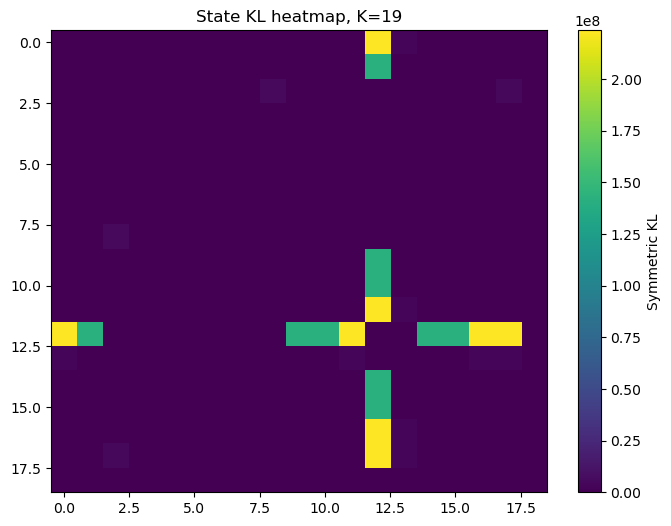

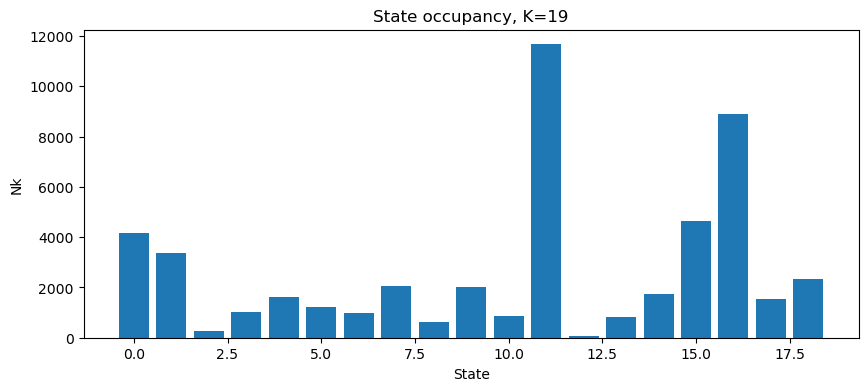

In [5]:
import matplotlib.pyplot as plt

gamma = np.load(os.path.join(save_dir, f"gamma_K_{best_K}.npy"))
Nk = gamma.sum(axis=0)

occupancy_df = pd.DataFrame({
    "state": np.arange(best_K),
    "Nk": Nk,
    "occupancy_frac": Nk / gamma.shape[0],
    "self_transition": np.diag(best_model["A"]),
})

print(occupancy_df.sort_values("occupancy_frac"))
report = redundancy_report(
    best_model,
    gamma=gamma,
    cov_type="diag",
    kl_thresh=2.0,
    A_row_thresh=0.20
)
flagged_df = pd.DataFrame(report["flagged_pairs"])
print(flagged_df.head(20) if len(flagged_df) > 0 else "No flagged pairs.")

plt.figure(figsize=(8,6))
plt.imshow(report["symKL"], aspect="auto")
plt.colorbar(label="Symmetric KL")
plt.title(f"State KL heatmap, K={best_K}")
plt.show()

plt.figure(figsize=(10,4))
plt.bar(np.arange(best_K), Nk)
plt.title(f"State occupancy, K={best_K}")
plt.xlabel("State")
plt.ylabel("Nk")
plt.show()

In [6]:
means_df = pd.DataFrame(
    best_model["mus"],
    columns=["dmid", "ofi", "inv_depth"]
)

means_df["state"] = np.arange(best_K)

print(means_df.sort_values("ofi"))

        dmid       ofi  inv_depth  state
5  -0.130803 -0.634660  -0.298229      5
10 -0.020116 -0.443844  -0.172684     10
12 -0.063201 -0.157315   0.051701     12
2  -0.000338 -0.030001  -0.224321      2
3  -0.010942 -0.027813  -0.099133      3
6  -0.000690 -0.006619   1.067282      6
1   0.000184 -0.006615  -0.200312      1
14  0.000184 -0.005046  -0.015077     14
9   0.000184 -0.003700  -0.363555      9
7  -0.002739 -0.001259   0.234801      7
8  -0.025759  0.000188   3.415149      8
16  0.000184  0.005059  -0.158211     16
11  0.000184  0.005059  -0.313060     11
0   0.000184  0.005059   0.284426      0
17  0.000184  0.005059   3.138687     17
18 -0.000149  0.017246  -0.154832     18
15  0.000184  0.020520  -0.293723     15
13  0.052531  0.083194  -0.322995     13
4   0.104236  0.573024  -0.290439      4


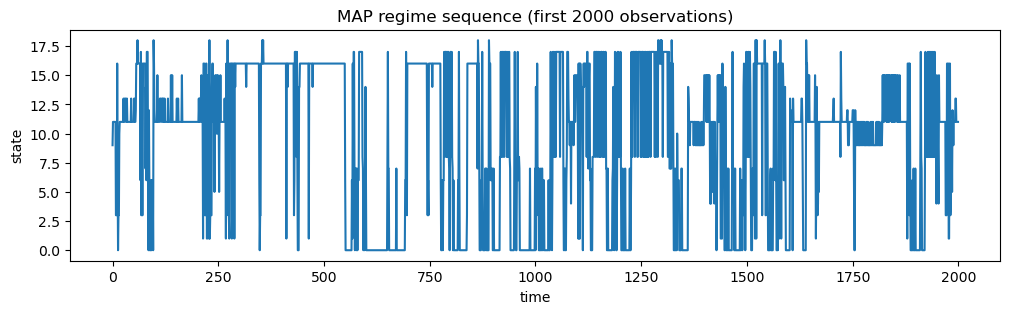

In [7]:
z = np.argmax(gamma, axis=1)

plt.figure(figsize=(12,3))
plt.plot(z[:2000])
plt.title("MAP regime sequence (first 2000 observations)")
plt.xlabel("time")
plt.ylabel("state")
plt.show()

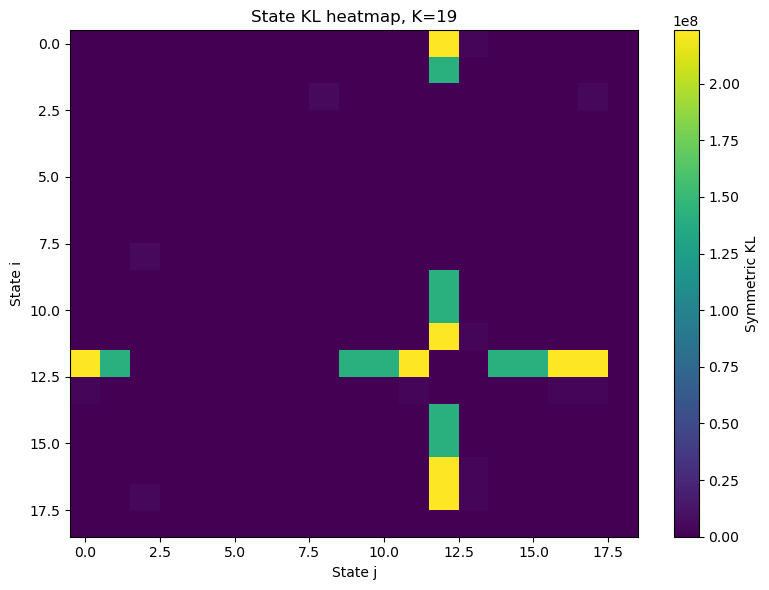

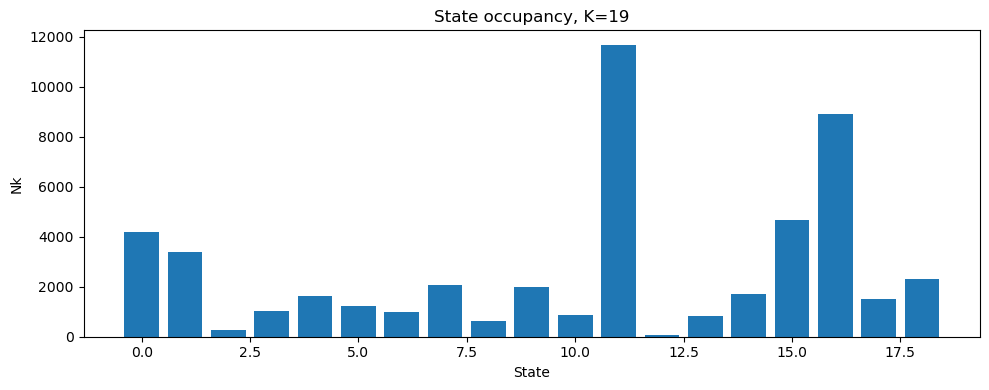

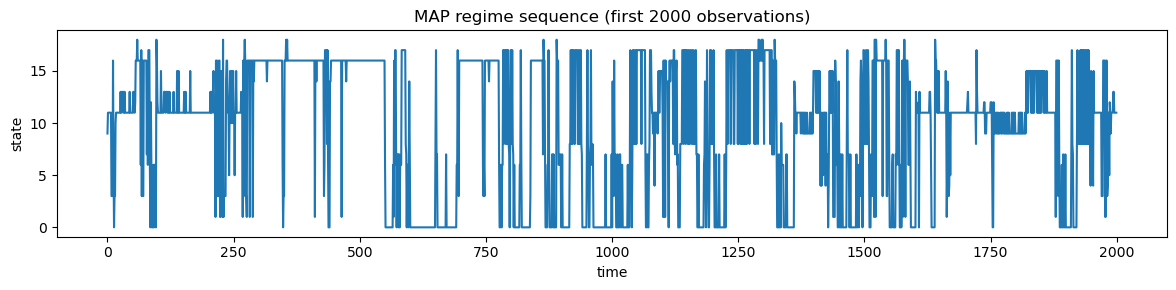

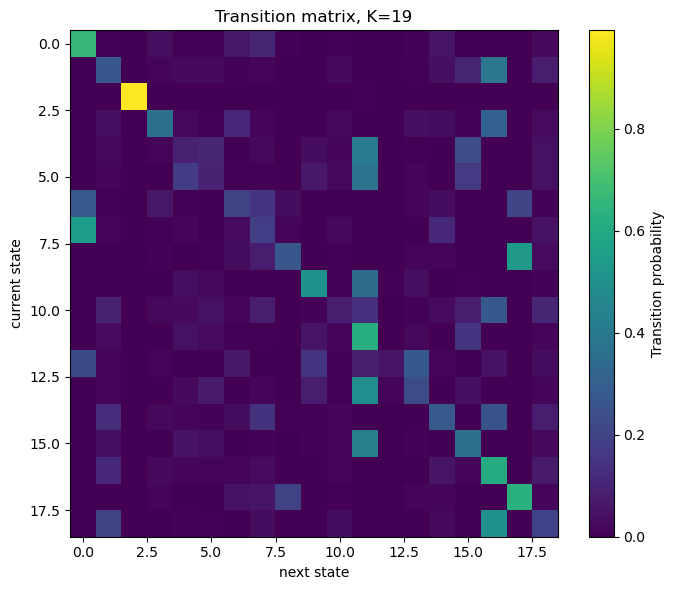

All diagnostics saved to:
C:\Users\USER\Desktop\MS -Thesis\Results\hmm_3d_diag_50k


In [8]:
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir, f"gamma_K_{best_K}.npy"), gamma)
np.save(os.path.join(save_dir, f"Nk_K_{best_K}.npy"), Nk)
np.save(os.path.join(save_dir, f"map_path_K_{best_K}.npy"), z)
np.save(os.path.join(save_dir, f"transition_matrix_K_{best_K}.npy"), best_model["A"])
joblib.dump(best_model, os.path.join(save_dir, f"best_model_K_{best_K}.joblib"))

occupancy_df.to_csv(
    os.path.join(save_dir, f"state_occupancy_K_{best_K}.csv"),
    index=False
)

means_df.to_csv(
    os.path.join(save_dir, f"state_means_K_{best_K}.csv"),
    index=False
)

flagged_df.to_csv(
    os.path.join(save_dir, f"redundancy_pairs_K_{best_K}.csv"),
    index=False
)

symKL_df = pd.DataFrame(report["symKL"])
symKL_df.to_csv(
    os.path.join(save_dir, f"symKL_matrix_K_{best_K}.csv"),
    index=False
)

summary = {
    "best_K": int(best_K),
    "n_states": int(best_K),
    "n_obs": int(gamma.shape[0]),
    "min_occupancy_frac": float(occupancy_df["occupancy_frac"].min()),
    "max_occupancy_frac": float(occupancy_df["occupancy_frac"].max()),
    "num_flagged_pairs": int(len(flagged_df)),
    "kl_thresh": float(report["kl_thresh"]) if report["kl_thresh"] is not None else None,
    "occ_thresh": float(report["occ_thresh"]) if report["occ_thresh"] is not None else None,
    "A_row_thresh": float(report["A_row_thresh"]) if report["A_row_thresh"] is not None else None,
}
with open(os.path.join(save_dir, f"diagnostics_summary_K_{best_K}.json"), "w") as f:
    json.dump(summary, f, indent=4)

plt.figure(figsize=(8, 6))
plt.imshow(report["symKL"], aspect="auto")
plt.colorbar(label="Symmetric KL")
plt.title(f"State KL heatmap, K={best_K}")
plt.xlabel("State j")
plt.ylabel("State i")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"KL_heatmap_K_{best_K}.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(np.arange(best_K), Nk)
plt.title(f"State occupancy, K={best_K}")
plt.xlabel("State")
plt.ylabel("Nk")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"occupancy_K_{best_K}.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(z[:2000])
plt.title("MAP regime sequence (first 2000 observations)")
plt.xlabel("time")
plt.ylabel("state")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"regime_sequence_K_{best_K}.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(best_model["A"], aspect="auto")
plt.colorbar(label="Transition probability")
plt.title(f"Transition matrix, K={best_K}")
plt.xlabel("next state")
plt.ylabel("current state")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"transition_matrix_K_{best_K}.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"All diagnostics saved to:\n{save_dir}")